In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/training_v2.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (91713, 186)

Columns: ['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min

In [2]:
# Check target variable distribution
print("Target variable - hospital_death:")
print(df['hospital_death'].value_counts())
print("\nDeath rate:", round(df['hospital_death'].mean() * 100, 2), "%")

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
}).sort_values('missing_percent', ascending=False)

print("\nTop 20 columns with most missing values:")
print(missing_df.head(20))

Target variable - hospital_death:
hospital_death
0    83798
1     7915
Name: count, dtype: int64

Death rate: 8.63 %

Top 20 columns with most missing values:
                      missing_count  missing_percent
h1_bilirubin_min              84619        92.265001
h1_bilirubin_max              84619        92.265001
h1_lactate_min                84369        91.992411
h1_lactate_max                84369        91.992411
h1_albumin_max                83824        91.398166
h1_albumin_min                83824        91.398166
h1_pao2fio2ratio_min          80195        87.441257
h1_pao2fio2ratio_max          80195        87.441257
h1_arterial_ph_max            76424        83.329517
h1_arterial_ph_min            76424        83.329517
h1_hco3_max                   76094        82.969699
h1_hco3_min                   76094        82.969699
h1_arterial_pco2_max          75959        82.822501
h1_arterial_pco2_min          75959        82.822501
h1_wbc_max                    75953        82.

In [3]:
# Select only the columns we need for PulseAlert
# Drop h1_ columns (too many missing) and keep d1_ (day 1) columns

pulse_features = [
    # Target
    'hospital_death',
    
    # Demographics
    'age', 'gender', 'weight', 'height', 'bmi',
    'elective_surgery', 'icu_type', 'icu_admit_source',
    
    # Vitals - Day 1
    'd1_heartrate_max', 'd1_heartrate_min',
    'd1_sysbp_max', 'd1_sysbp_min',
    'd1_diasbp_max', 'd1_diasbp_min',
    'd1_mbp_max', 'd1_mbp_min',
    'd1_resprate_max', 'd1_resprate_min',
    'd1_spo2_max', 'd1_spo2_min',
    'd1_temp_max', 'd1_temp_min',
    
    # Labs - Day 1
    'd1_lactate_max', 'd1_lactate_min',
    'd1_creatinine_max', 'd1_creatinine_min',
    'd1_wbc_max', 'd1_wbc_min',
    'd1_hemaglobin_max', 'd1_hemaglobin_min',
    'd1_glucose_max', 'd1_glucose_min',
    'd1_bun_max', 'd1_bun_min',
    'd1_sodium_max', 'd1_sodium_min',
    'd1_potassium_max', 'd1_potassium_min',
    
    # APACHE scores (severity of illness)
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
    'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache',
    'heart_rate_apache', 'map_apache', 'temp_apache',
    'creatinine_apache', 'bun_apache', 'wbc_apache',
    
    # Comorbidities
    'aids', 'cirrhosis', 'diabetes_mellitus',
    'hepatic_failure', 'immunosuppression',
    'solid_tumor_with_metastasis'
]

# Create working dataframe
df_pulse = df[pulse_features].copy()

print("PulseAlert dataset shape:", df_pulse.shape)
print("\nMissing values summary:")
print(df_pulse.isnull().sum().sort_values(ascending=False).head(20))

PulseAlert dataset shape: (91713, 56)

Missing values summary:
d1_lactate_max                   68396
d1_lactate_min                   68396
wbc_apache                       22012
bun_apache                       19262
creatinine_apache                18853
d1_wbc_min                       13174
d1_wbc_max                       13174
d1_hemaglobin_min                12147
d1_hemaglobin_max                12147
d1_bun_min                       10514
d1_bun_max                       10514
d1_sodium_min                    10195
d1_sodium_max                    10195
d1_creatinine_min                10169
d1_creatinine_max                10169
d1_potassium_max                  9585
d1_potassium_min                  9585
apache_4a_hospital_death_prob     7947
apache_4a_icu_death_prob          7947
d1_glucose_min                    5807
dtype: int64


Missing percentage for key columns:
d1_lactate_max                   74.576123
d1_lactate_min                   74.576123
wbc_apache                       24.000960
bun_apache                       21.002475
creatinine_apache                20.556519
d1_wbc_min                       14.364376
d1_wbc_max                       14.364376
d1_hemaglobin_min                13.244578
d1_hemaglobin_max                13.244578
d1_bun_min                       11.464024
d1_bun_max                       11.464024
d1_sodium_min                    11.116199
d1_sodium_max                    11.116199
d1_creatinine_min                11.087850
d1_creatinine_max                11.087850
d1_potassium_max                 10.451081
d1_potassium_min                 10.451081
apache_4a_hospital_death_prob     8.665075
apache_4a_icu_death_prob          8.665075
d1_glucose_min                    6.331709
dtype: float64


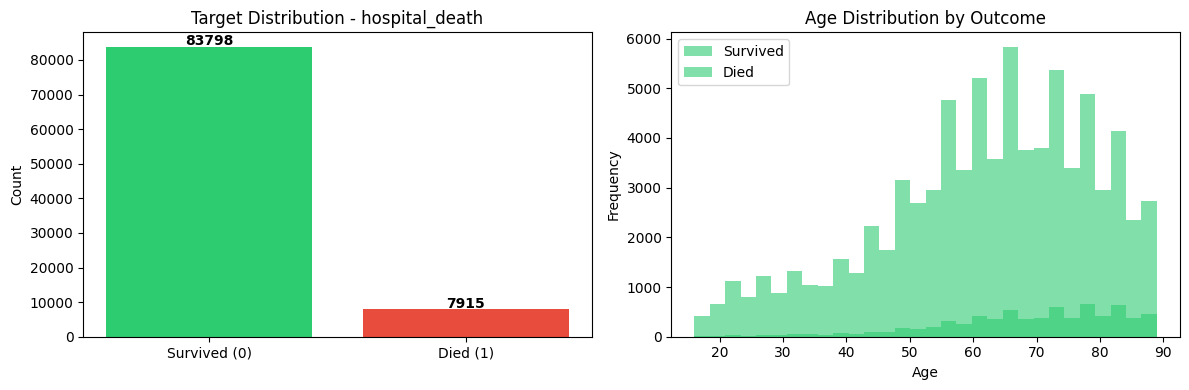


Age stats by outcome:
                  count       mean        std   min   25%   50%   75%   max
hospital_death                                                             
0               80212.0  61.748741  16.860137  16.0  52.0  64.0  75.0  89.0
1                7273.0  68.494156  14.428363  16.0  60.0  71.0  80.0  89.0


In [4]:
# Check missing percentage for key columns
missing_pct = (df_pulse.isnull().sum() / len(df_pulse)) * 100
print("Missing percentage for key columns:")
print(missing_pct.sort_values(ascending=False).head(20))

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - Target distribution
axes[0].bar(['Survived (0)', 'Died (1)'], 
            df_pulse['hospital_death'].value_counts().values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Distribution - hospital_death')
axes[0].set_ylabel('Count')
for i, v in enumerate(df_pulse['hospital_death'].value_counts().values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Plot 2 - Age distribution by outcome
df_pulse.groupby('hospital_death')['age'].plot(
    kind='hist', bins=30, alpha=0.6, ax=axes[1],
    color=['#2ecc71', '#e74c3c'], legend=True
)
axes[1].set_title('Age Distribution by Outcome')
axes[1].set_xlabel('Age')
axes[1].legend(['Survived', 'Died'])

plt.tight_layout()
plt.show()

print("\nAge stats by outcome:")
print(df_pulse.groupby('hospital_death')['age'].describe())

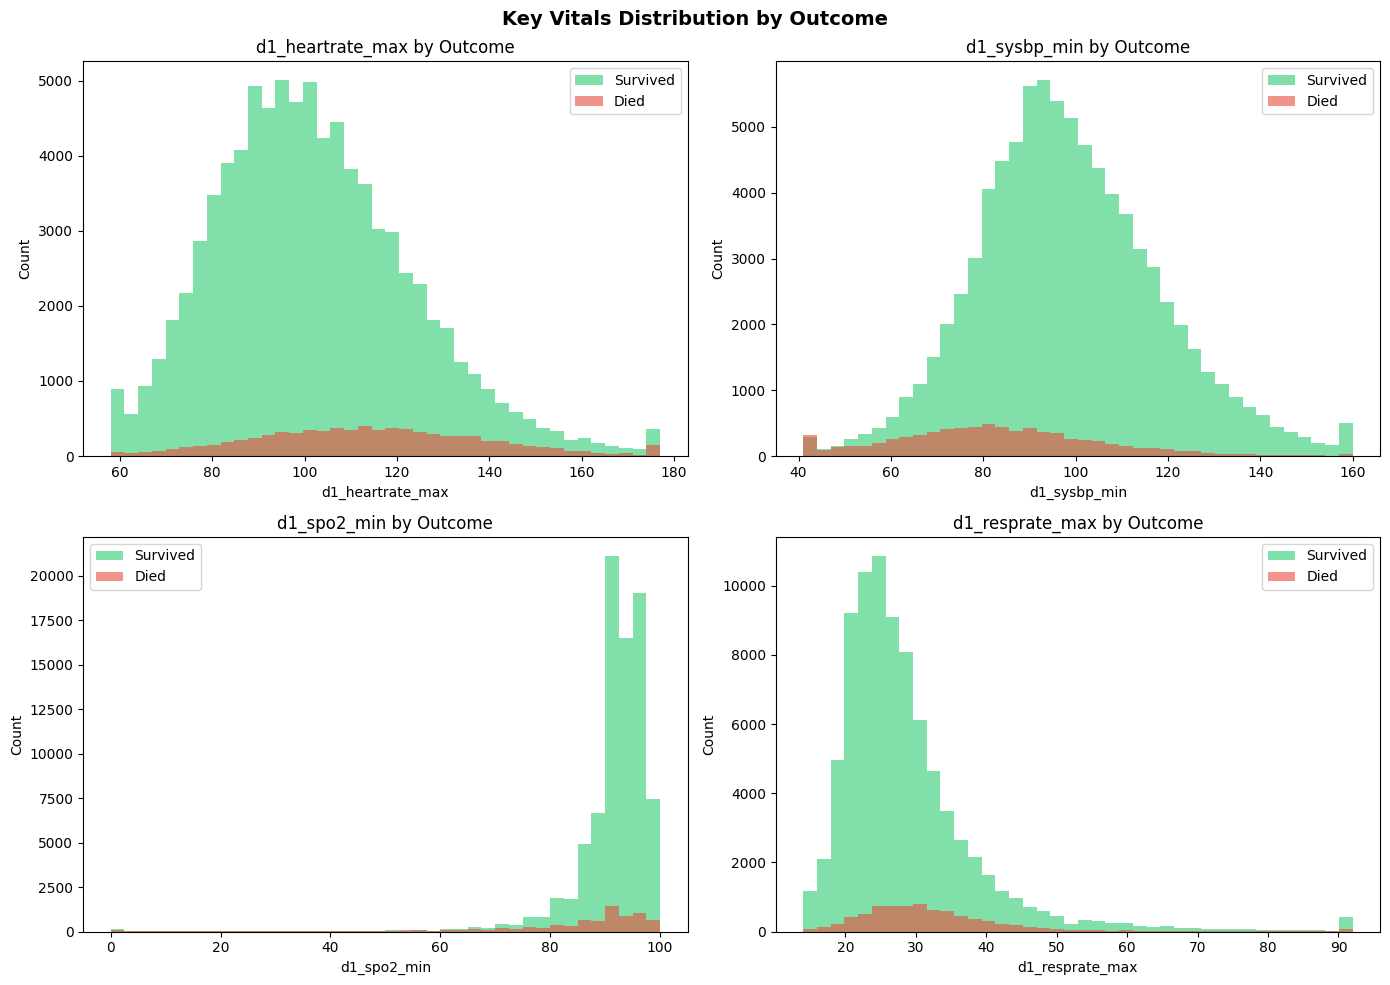

Mean vitals by outcome:
                d1_heartrate_max  d1_sysbp_min  d1_spo2_min  d1_resprate_max
hospital_death                                                              
0                         101.90         98.26        91.10            28.54
1                         114.68         82.77        83.59            32.48


In [5]:
# Visualize key vitals by outcome
vitals = [
    'd1_heartrate_max', 'd1_sysbp_min', 
    'd1_spo2_min', 'd1_resprate_max'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c']
labels = ['Survived', 'Died']

for i, col in enumerate(vitals):
    for outcome, color, label in zip([0, 1], colors, labels):
        data = df_pulse[df_pulse['hospital_death'] == outcome][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.6, color=color, label=label)
    
    axes[i].set_title(f'{col} by Outcome')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Key Vitals Distribution by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print mean values
print("Mean vitals by outcome:")
print(df_pulse.groupby('hospital_death')[vitals].mean().round(2))

Top 15 features most correlated with death:
d1_lactate_min                   0.403614
d1_lactate_max                   0.399029
apache_4a_hospital_death_prob    0.311043
apache_4a_icu_death_prob         0.283913
gcs_motor_apache                 0.282449
gcs_eyes_apache                  0.260373
gcs_verbal_apache                0.241044
d1_sysbp_min                     0.210170
d1_spo2_min                      0.210100
d1_temp_min                      0.207239
d1_mbp_min                       0.195262
d1_bun_max                       0.186558
bun_apache                       0.181435
d1_bun_min                       0.181383
d1_diasbp_min                    0.179559
Name: hospital_death, dtype: float64


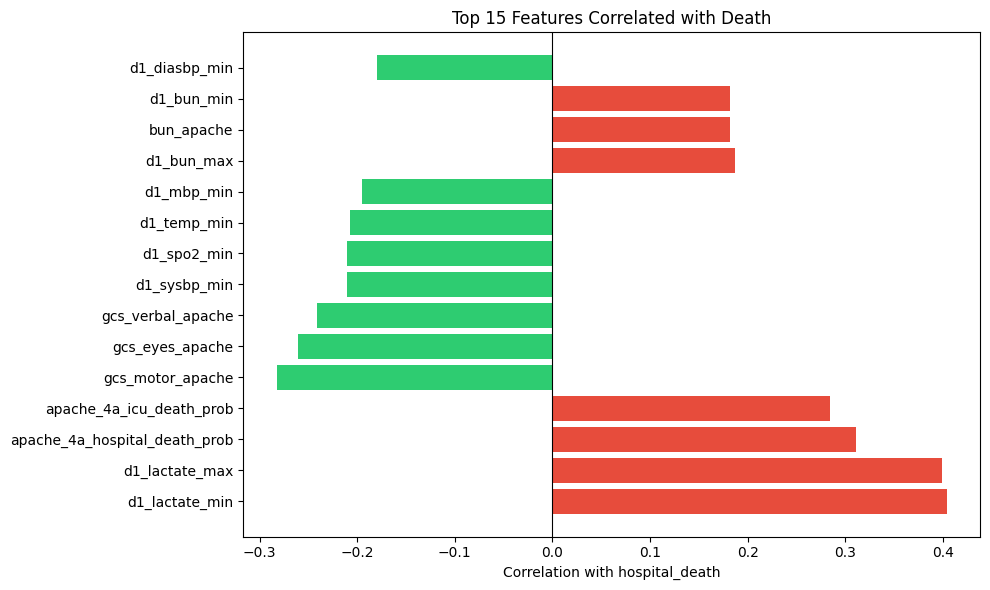


Notebook 01 - Data Exploration COMPLETE ✅
Key findings:
  - Dataset: 91713 patients, 56 features
  - Death rate: 8.63% (imbalanced - need SMOTE)
  - Avg age of deaths: 68.5 vs 61.7 for survivors
  - Key predictors: SpO2, Systolic BP, Heart Rate, Resp Rate


In [6]:
# Correlation with target
numeric_cols = df_pulse.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_pulse[numeric_cols].corr()['hospital_death'].drop('hospital_death')
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("Top 15 features most correlated with death:")
print(correlations_sorted.head(15))

# Plot top 15 correlations
plt.figure(figsize=(10, 6))
top15 = correlations.loc[correlations_sorted.head(15).index]
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top15.values]
plt.barh(top15.index, top15.values, color=colors)
plt.xlabel('Correlation with hospital_death')
plt.title('Top 15 Features Correlated with Death')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nNotebook 01 - Data Exploration COMPLETE ✅")
print("Key findings:")
print(f"  - Dataset: {df_pulse.shape[0]} patients, {df_pulse.shape[1]} features")
print(f"  - Death rate: 8.63% (imbalanced - need SMOTE)")
print(f"  - Avg age of deaths: 68.5 vs 61.7 for survivors")
print(f"  - Key predictors: SpO2, Systolic BP, Heart Rate, Resp Rate")